In [8]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos, sin
from matplotlib.gridspec import GridSpec
import scipy.interpolate as sciint
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [87]:
project='incTel'
ed='run4/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='dynDiagTrac'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(ds.T) 

if project=='twoBumps':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)+1

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
else:
    umbral=np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0][int(len(np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0])/2)]
    umbralEnd=np.where(dsG.Depth[:,20]<np.max(dsG.Depth[:,20]))[0][-1]

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth' or project =='Orlanski':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=1
    OBendx=-1

In [99]:
dsG

<xarray.Dataset> Size: 27MB
Dimensions:  (Z: 80, Zp1: 81, Zu: 80, Zl: 80, X: 40, Y: 320, Xp1: 41, Yp1: 321)
Coordinates:
  * Z        (Z) float64 640B -8.0 -24.0 -40.0 ... -1.256e+03 -1.272e+03
  * Zp1      (Zp1) float64 648B 0.0 -16.0 -32.0 ... -1.264e+03 -1.28e+03
  * Zu       (Zu) float64 640B -16.0 -32.0 -48.0 ... -1.264e+03 -1.28e+03
  * Zl       (Zl) float64 640B 0.0 -16.0 -32.0 ... -1.248e+03 -1.264e+03
  * X        (X) float64 320B 250.0 750.0 1.25e+03 ... 1.925e+04 1.975e+04
  * Y        (Y) float64 3kB 1.374e+03 4.088e+03 ... 2.966e+05 3.001e+05
  * Xp1      (Xp1) float64 328B 0.0 500.0 1e+03 ... 1.9e+04 1.95e+04 2e+04
  * Yp1      (Yp1) float64 3kB 0.0 2.747e+03 5.428e+03 ... 2.983e+05 3.018e+05
Data variables: (12/30)
    RC       (Z) float64 640B ...
    RF       (Zp1) float64 648B ...
    RU       (Zu) float64 640B ...
    RL       (Zl) float64 640B ...
    drC      (Zp1) float64 648B ...
    drF      (Z) float64 640B ...
    ...       ...
    R_low    (Y, X) float64 102kB ...
    Ro_surf  (Y, X) float64 102kB ...
    Depth    (Y, X) float64 102kB ...
    HFacC    (Z, Y, X) float64 8MB 0.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 0.0
    HFacW    (Z, Y, Xp1) float64 8MB 0.0 0.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 0.0 0.0
    HFacS    (Z, Yp1, X) float64 8MB 0.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 0.0
Attributes: (12/18)
    MITgcm_version:  checkpoint69g
    build_user:      amelia.th
    build_host:      tsunami
    build_date:      vie 24 oct 2025 11:37:19 PDT
    MITgcm_URL:      http://mitgcm.org
    MITgcm_tag_id:   
    ...              ...
    nSy:             1
    nPx:             2
    nPy:             5
    Nx:              40
    Ny:              320
    Nr:              80

In [88]:
start=np.where(ds.T/(60*60*24*360)>=1)[0][0]
end =np.where(ds.T/(60*60*24*360)<=3)[0][-1] # np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1] #

#### One sill

In [89]:
depindUmb=np.where(dsG.Z<-400)[0][0]
depind800=np.where(dsG.Z<-800)[0][0]-1

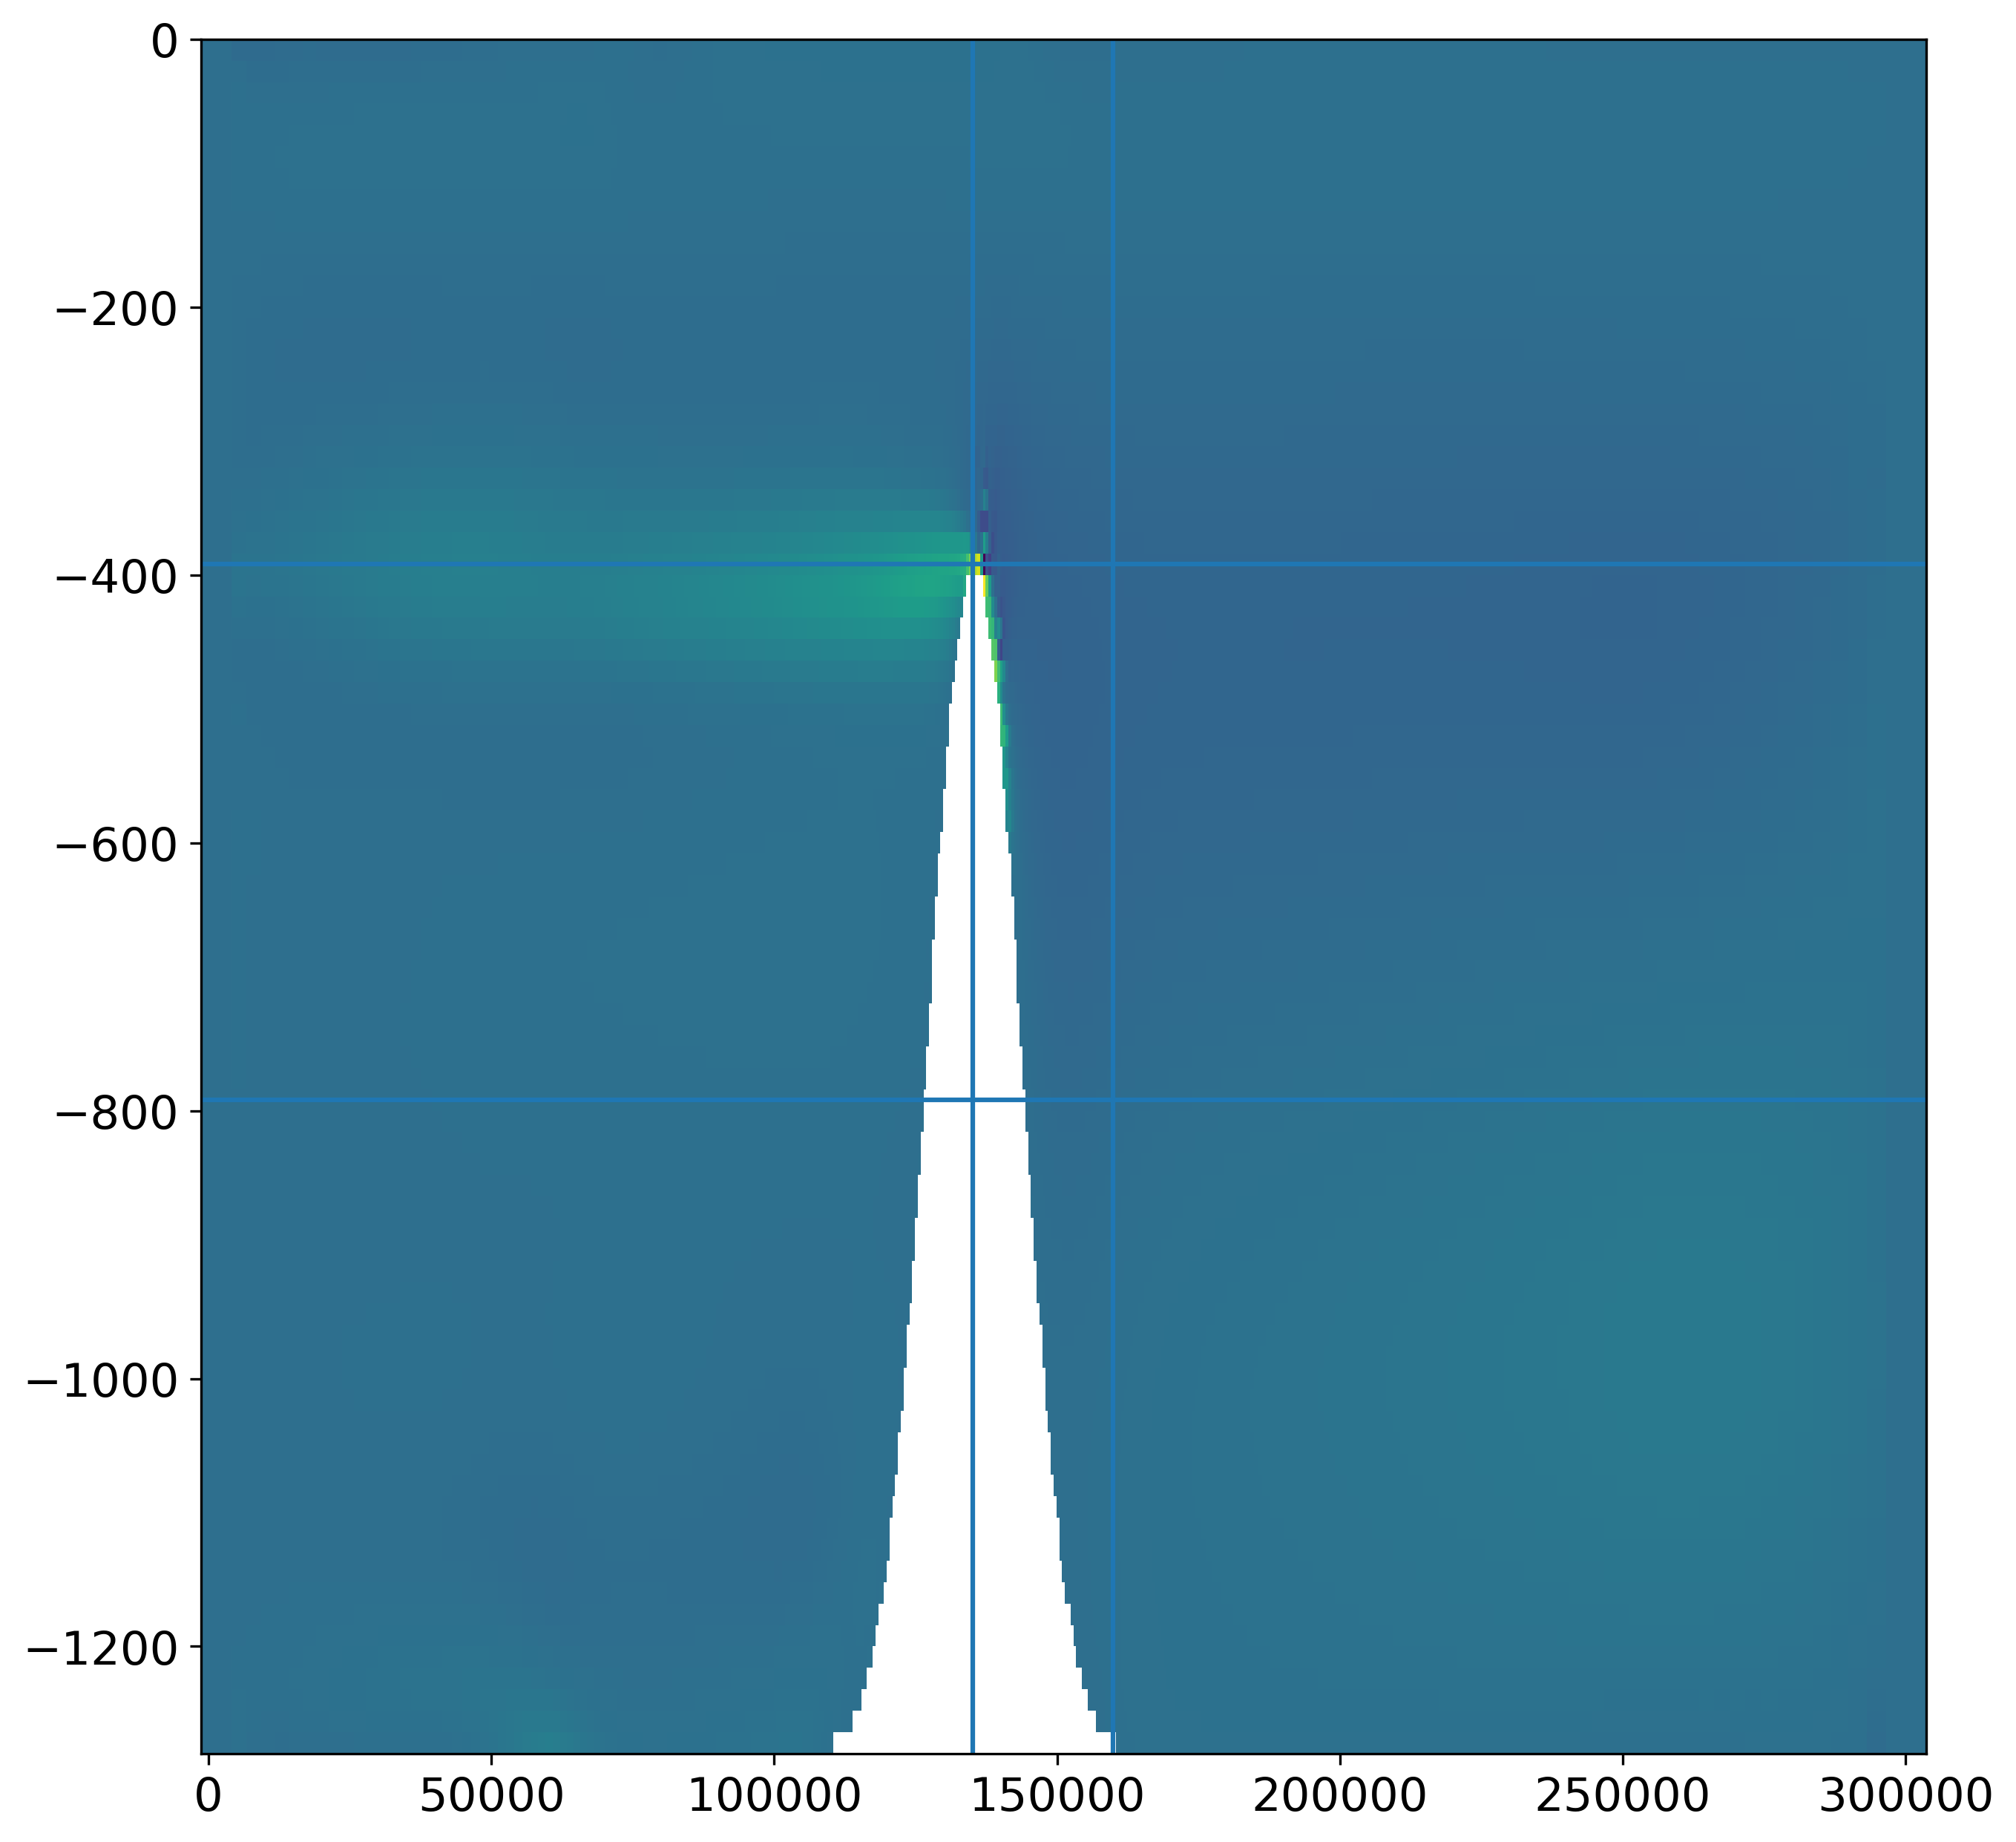

In [90]:
plt.pcolormesh(dsG.Yp1,dsG.Z,np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,:,20],axis=0),mask=masks[:,:,20]))
plt.axvline(dsG.Yp1[umbral])
plt.axvline(dsG.Y[umbralEnd])
plt.axhline(dsG.Z[depindUmb-1])
plt.axhline(dsG.Z[depind800])

In [91]:
f'Total transport on first sill {np.sum(np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,umbral,:],axis=0),mask=masks[:,umbral,:])):.1f} kg/m^2/s'



'Total transport on first sill 5.8 kg/m^2/s'

In [106]:
f'Total upwelling transport after first sill at depth 400 m {np.sum(np.ma.masked_array(np.mean(ds.WRHOMASS[:,depindUmb-1,umbralEnd:OBend,:],axis=0)*dsG.rA[umbralEnd:OBend,:],mask=mask[depindUmb-1,umbralEnd:OBend,:])):.3f} kg/s'



'Total upwelling transport after first sill at depth 400 m 4295.653 kg/s'

In [107]:
f'Total upwelling transport after first sill at depth 800 m {np.sum(np.ma.masked_array(np.mean(ds.WRHOMASS[:,depind800-1,umbralEnd:OBend,:],axis=0)*dsG.rA[umbralEnd:OBend,:],mask=mask[depind800-1,umbralEnd:OBend,:])):.3f} kg/s'



'Total upwelling transport after first sill at depth 800 m 1700.557 kg/s'

#### Two sills 

In [79]:
depindUmb=np.where(dsG.Z<-600)[0][0]
depind800=np.where(dsG.Z<-800)[0][0]-1
umbralStart2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][0]+int(ny/2)


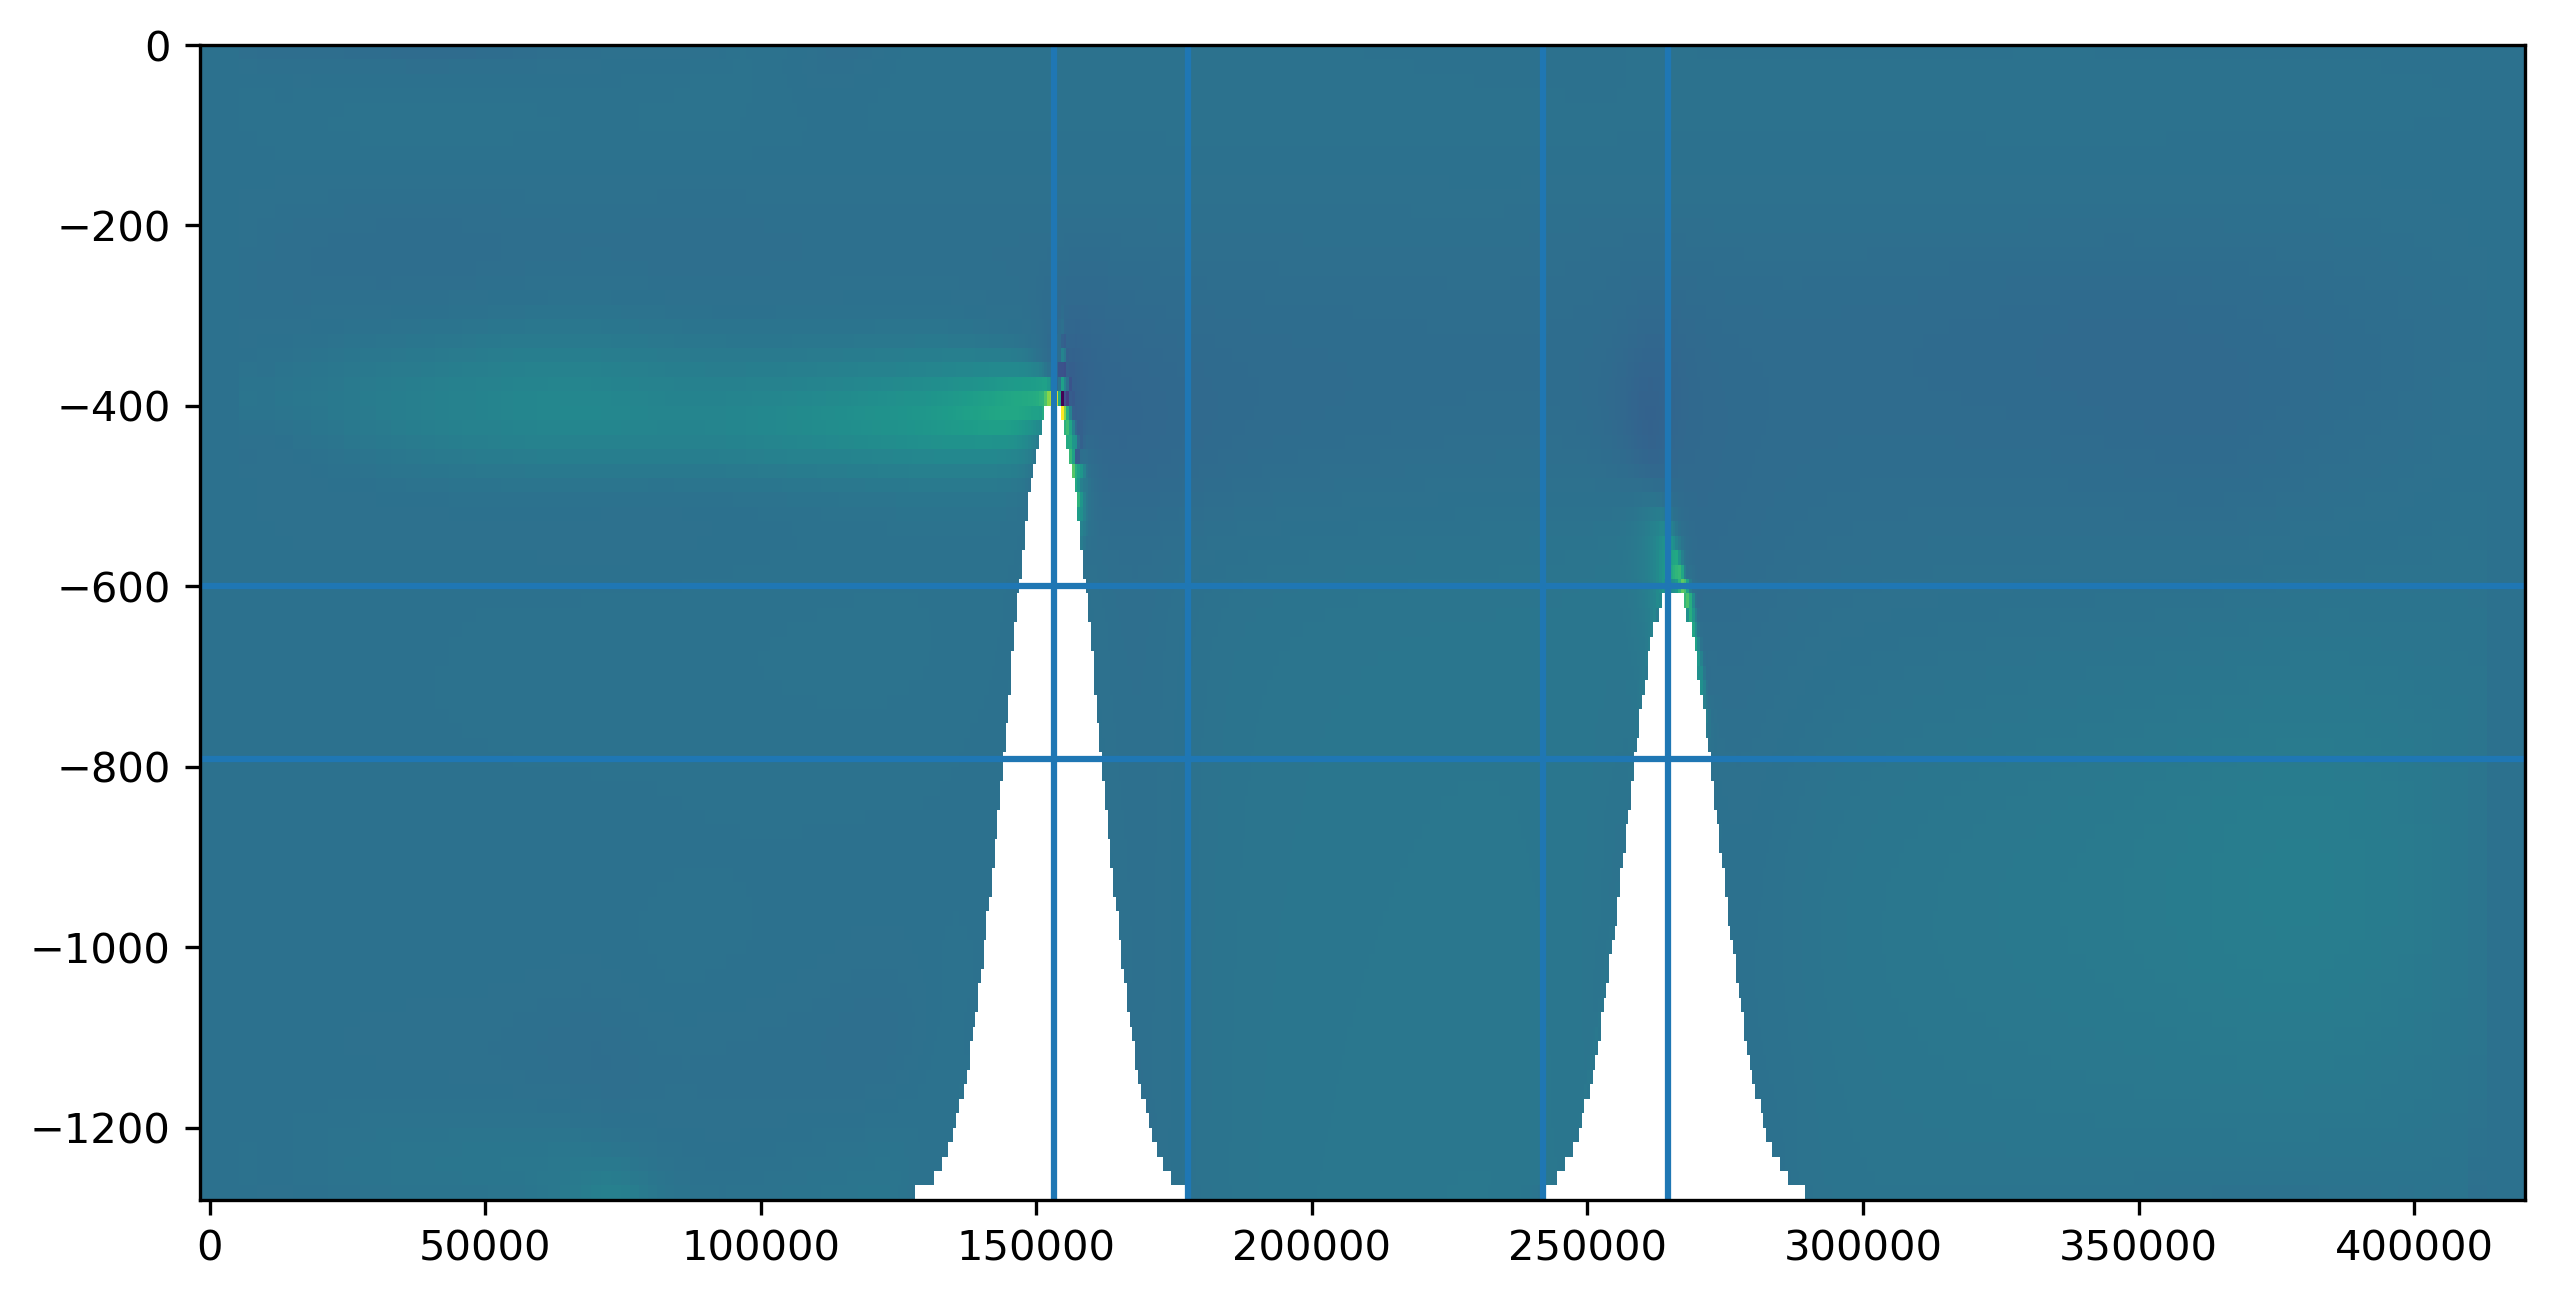

In [78]:
plt.pcolormesh(dsG.Yp1,dsG.Z,np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,:,20],axis=0),mask=masks[:,:,20]))
plt.axvline(dsG.Yp1[umbral1])
plt.axvline(dsG.Yp1[umbral2+1])
plt.axvline(dsG.Y[umbralEnd1])
plt.axvline(dsG.Y[umbralStart2])
plt.axhline(dsG.Z[depindUmb-1])
plt.axhline(dsG.Z[depind800])

In [80]:
f'Total upwelling transport after first sill at depth 600 m {np.sum(np.ma.masked_array(np.mean(ds.WRHOMASS[:,depindUmb-1,umbralEnd1:umbralStart2,:],axis=0),mask=mask[depindUmb-1,umbralEnd1:umbralStart2,:])):.3f} kg/m^2/s'



'Total upwelling transport after first sill at depth 600 m 0.019 kg/m^2/s'

In [81]:
f'Total upwelling transport after first sill at depth 800 m {np.sum(np.ma.masked_array(np.mean(ds.WRHOMASS[:,depind800-1,umbralEnd1:umbralStart2,:],axis=0),mask=mask[depind800-1,umbralEnd1:umbralStart2,:])):.3f} kg/m^2/s'



'Total upwelling transport after first sill at depth 800 m 0.021 kg/m^2/s'

In [33]:
f'Total transport on first sill {np.sum(np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,umbral1,:],axis=0),mask=masks[:,umbral2,:])):.1f} kg/m^2/s'



'Total transport on first sill 6.6 kg/m^2/s'

In [35]:
f'Total transport on second sill {np.sum(np.ma.masked_array(np.mean(ds.VRHOMASS[:,:,umbral2,:],axis=0),mask=masks[:,umbral2,:])):.1f} kg/m^2/s'



'Total transport on second sill 6.5 kg/m^2/s'

In [39]:
l=0
k=umbral
i=10
np.sum(np.mean(ds.VVEL[start:end,:,k,:].values,axis=0)[np.mean(ds.VVEL[start:end,:,k,:].values,axis=0)>0]*16*500)*1e-6

np.float32(0.14001681)

In [32]:
np.sum(np.mean(ds.VVEL[start:end,:,k,:].values,axis=0)[np.mean(ds.VVEL[start:end,:,k,:].values,axis=0)<0]*16*500)*1e-6

np.float32(-0.15395288)

## Vertical transport

In [56]:
indstartUp=umbralEnd
indendUp=umbralEnd
depindUmb=np.where(dsG.Z<-600)[0][0]
depind800=np.where(dsG.Z<-800)[0][0]-1

#### West

In [66]:
invel600=ds.WVEL[start:end,depindUmb,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]
invel800=ds.WVEL[start:end,depind800,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]

mask600=mask[depindUmb,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]
mask800=mask[depind800,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]

area600=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,OBx:int(len(dsG.X)/2)].values,mask=mask600)
area800=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,OBx:int(len(dsG.X)/2)].values,mask=mask800)


vel600=np.mean(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600))
vel800=np.mean(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800))

transp600=np.sum(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600)*area600)
transp800=np.sum(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800)*area800)


Experiment with two sills

In [52]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is 9.5e-05 m/s or 8.2e+00 m/day and at 800 m depth is 5.9e-05 m/s or 5.1e+00 m/day


In [53]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.1e} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.1e} Sv')



The transport at 600 m depth is 9.4e+04 m$^3$/s or 9.4e-02 Sv and at 800 m depth is 5.4e+04 m$^3$/s or 5.4e-02 Sv


#### East

In [54]:
invel600=ds.WVEL[start:end,depindUmb,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]
invel800=ds.WVEL[start:end,depind800,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]

mask600=mask[depindUmb,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]
mask800=mask[depind800,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]

area600=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,int(len(dsG.X)/2):OBendx].values,mask=mask600)
area800=np.ma.masked_array(dsG.rAs[indstartUp:indendUp,int(len(dsG.X)/2):OBendx].values,mask=mask800)

vel600=np.mean(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600))
vel800=np.mean(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800))

transp600=np.sum(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600)*area600)
transp800=np.sum(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800)*area800)


Experiment with two sills

In [55]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is -1.2e-04 m/s or -1.0e+01 m/day and at 800 m depth is -5.9e-05 m/s or -5.1e+00 m/day


In [56]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.1e} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.1e} Sv')



The transport at 600 m depth is -1.2e+05 m$^3$/s or -1.2e-01 Sv and at 800 m depth is -5.4e+04 m$^3$/s or -5.4e-02 Sv


#### All

In [156]:
invel600=ds.WVEL[start:end,depindUmb,indstartUp:indendUp,OBx:OBendx]
invel800=ds.WVEL[start:end,depind800,indstartUp:indendUp,OBx:OBendx]

mask600=mask[depindUmb,indstartUp:indendUp,OBx:OBendx]
mask800=mask[depind800,indstartUp:indendUp,OBx:OBendx]

area600=np.ma.masked_array(dsG.rA[indstartUp:indendUp,OBx:OBendx].values,mask=mask600)
area800=np.ma.masked_array(dsG.rA[indstartUp:indendUp,OBx:OBendx].values,mask=mask800)


vel600=np.mean(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600))
vel800=np.mean(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800))

transp600=np.sum(np.ma.masked_array(np.mean(invel600,axis=0),mask=mask600)*area600)
transp800=np.sum(np.ma.masked_array(np.mean(invel800,axis=0),mask=mask800)*area800)


In [157]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.2f} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.2f} Sv')



The transport at 600 m depth is -4.7e-03 m$^3$/s or -0.00 Sv and at 800 m depth is 2.7e-03 m$^3$/s or 0.00 Sv


## Experiment with two sills 
Frac 1

In [158]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is 0.0e+00 m/s or 0.0e+00 m/day and at 800 m depth is 8.1e-12 m/s or 7.0e-07 m/day


In [159]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.2f} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.2f} Sv')



The transport at 600 m depth is -4.7e-03 m$^3$/s or -0.00 Sv and at 800 m depth is 2.7e-03 m$^3$/s or 0.00 Sv


Experiment with two sills 
Frac 0.5

In [121]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is -9.1e-06 m/s or -7.8e-01 m/day and at 800 m depth is 0.0e+00 m/s or 0.0e+00 m/day


In [122]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.2f} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.2f} Sv')



The transport at 600 m depth is -1.8e+04 m$^3$/s or -0.02 Sv and at 800 m depth is 4.3e-04 m$^3$/s or 0.00 Sv


Experiment with two sills 
Frac 0.1

In [127]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is -8.9e-06 m/s or -7.7e-01 m/day and at 800 m depth is 1.6e-11 m/s or 1.4e-06 m/day


In [128]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.2f} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.2f} Sv')



The transport at 600 m depth is -1.8e+04 m$^3$/s or -0.02 Sv and at 800 m depth is -2.1e-04 m$^3$/s or -0.00 Sv


### Experiment with ONE sills 
Frac 1

In [109]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is -4.5e-05 m/s or -3.9e+00 m/day and at 800 m depth is -7.7e-05 m/s or -6.6e+00 m/day


In [110]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.2f} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.2f} Sv')



The transport at 600 m depth is -5.1e+04 m$^3$/s or -0.05 Sv and at 800 m depth is -8.2e+04 m$^3$/s or -0.08 Sv


Experiment with two sills 
Frac 0.5

In [96]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is -4.0e-05 m/s or -3.5e+00 m/day and at 800 m depth is -7.3e-05 m/s or -6.3e+00 m/day


In [97]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.2f} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.2f} Sv')



The transport at 600 m depth is -4.5e+04 m$^3$/s or -0.04 Sv and at 800 m depth is -7.5e+04 m$^3$/s or -0.08 Sv


Experiment with two sills 
Frac 0.1

In [103]:
print(f'The upwelling velocity at 600 m depth is {vel600:.1e} m/s or {vel600*86400:.1e} m/day and at 800 m depth is {vel800:.1e} m/s or {vel800*86400:.1e} m/day')

The upwelling velocity at 600 m depth is -4.4e-05 m/s or -3.8e+00 m/day and at 800 m depth is -7.6e-05 m/s or -6.6e+00 m/day


In [104]:
print(f'The transport at 600 m depth is {transp600:.1e} m$^3$/s or {transp600*1e-6:.2f} Sv and at 800 m depth is {transp800:.1e} m$^3$/s or {transp800*1e-6:.2f} Sv')



The transport at 600 m depth is -5.1e+04 m$^3$/s or -0.05 Sv and at 800 m depth is -8.1e+04 m$^3$/s or -0.08 Sv


#### Plotting

In [54]:
params = {'font.size': 10,
          'figure.figsize': (10, 5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

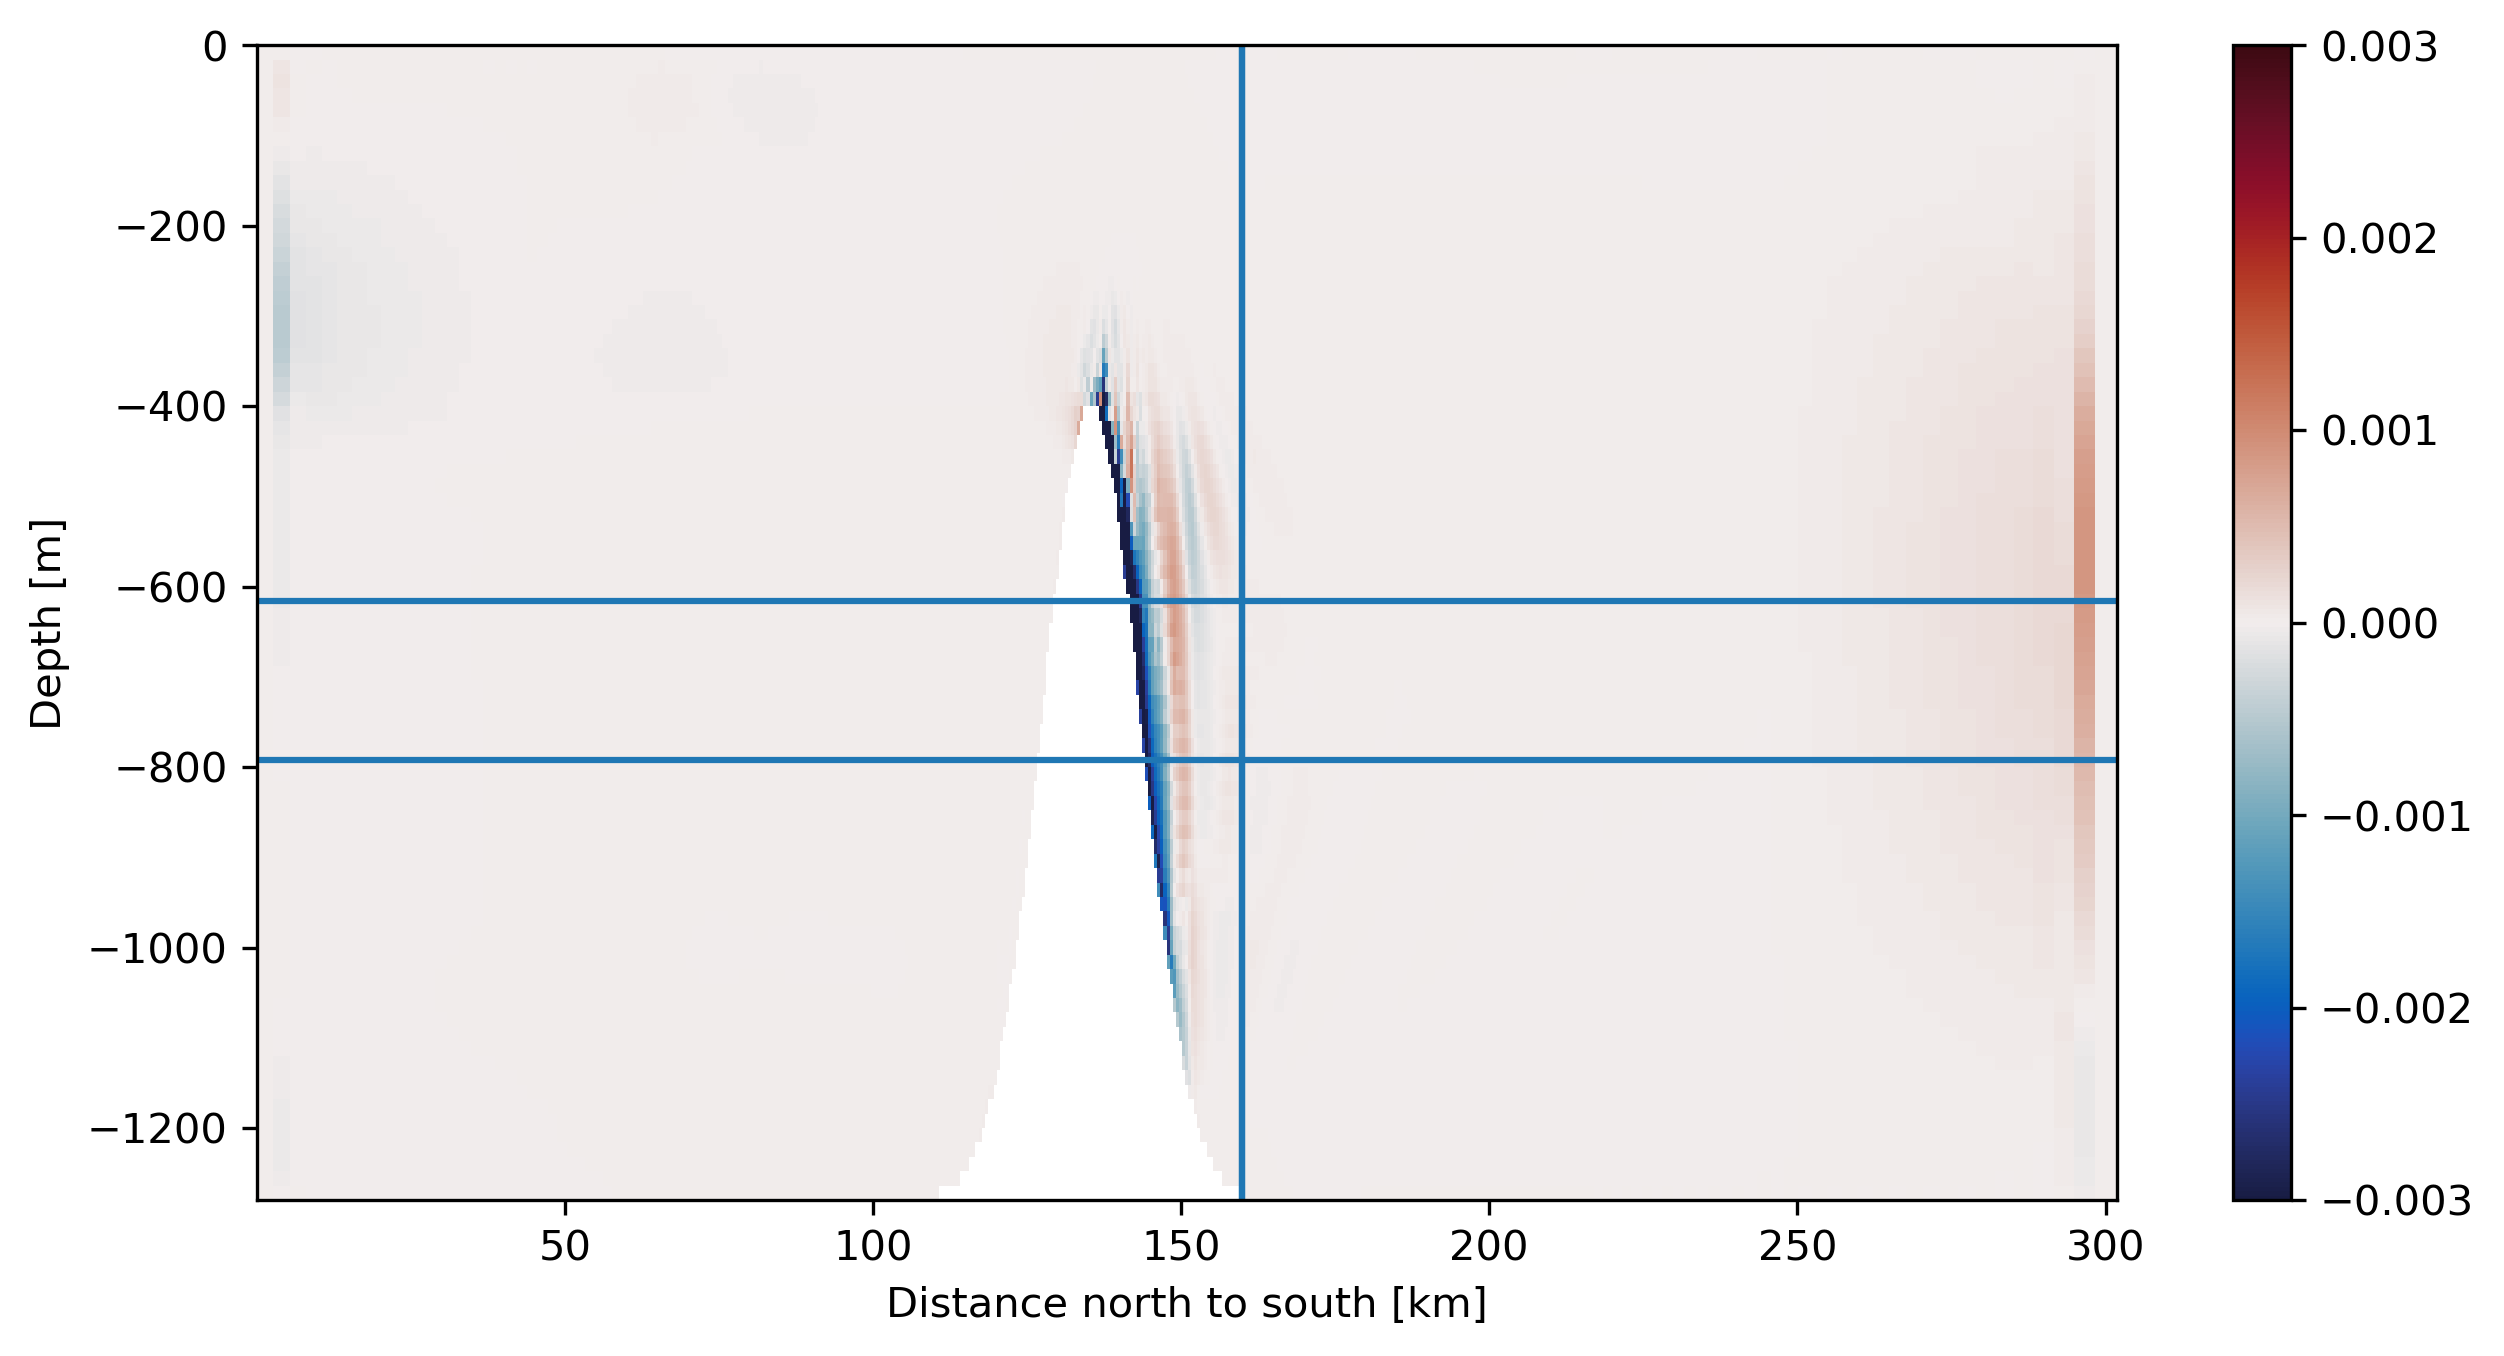

In [57]:
fig,ax=plt.subplots()
cax=ax.pcolormesh(dsG.Y/1000,dsG.Z,np.mean(np.ma.masked_array(np.mean(ds.WVEL[start:end,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=2),vmin=-0.003,vmax=0.003,cmap=cmocean.cm.balance)
ax.axvline(dsG.Y[indstartUp]/1000)
ax.axvline(dsG.Y[indendUp]/1000)
ax.axhline(dsG.Z[depindUmb])
ax.axhline(dsG.Z[depind800])
ax.set(xlabel='Distance north to south [km]',ylabel='Depth [m]')


#ax.text(0.57, 0.05, f'Average within \nthese lines: {np.mean(np.ma.masked_array(np.mean(ds.WVEL[start:end,depindUmb,indstartUp:indendUp,OBx:OBendx],axis=0),mask=mask[depindUmb,indstartUp:indendUp,OBx:OBendx]))*86400:.3g} m/day\nor{(np.mean(np.ma.masked_array(np.mean(ds.WVEL[start:end,depindUmb:,indstartUp:indendUp,OBx:OBendx],axis=0),mask=mask[depindUmb:,indstartUp:indendUp,OBx:OBendx]))*((dsG.Y[indendUp]-dsG.Y[indstartUp])*(dsG.X[OBx:OBendx]-dsG.X[OBx])[-1]))*1e-6:.3g} Sv', color='k', 
 #       transform=ax.transAxes,fontsize=8)

#ax.text(0.57, 0.2, f'Average within \nthese lines\nWest side: {np.mean(np.ma.masked_array(np.mean(ds.WVEL[start:end,depindUmb,indstartUp:indendUp,OBx:int(len(dsG.X)/2)],axis=0),mask=mask[depindUmb,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]))*86400:.3g} m/day\nor {(np.mean(np.ma.masked_array(np.mean(ds.WVEL[start:end,depindUmb:,indstartUp:indendUp,OBx:int(len(dsG.X)/2)],axis=0),mask=mask[depindUmb:,indstartUp:indendUp,OBx:int(len(dsG.X)/2)]))*((dsG.Y[indendUp]-dsG.Y[indstartUp])*(dsG.X[OBx:int(len(dsG.X)/2)]-dsG.X[OBx])[-1]))*1e-6:.3g} Sv', color='k', 
#        transform=ax.transAxes,fontsize=8)

#ax.text(0.57, 0.4, f'Average within \nthese lines\nEast side: {np.mean(np.ma.masked_array(np.mean(ds.WVEL[start:end,depindUmb,indstartUp:indendUp,int(len(dsG.X)/2):OBendx],axis=0),mask=mask[depindUmb,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]))*86400:.3g} m/day\nor {(np.mean(np.ma.masked_array(np.mean(ds.WVEL[start:end,depindUmb:,indstartUp:indendUp,int(len(dsG.X)/2):OBendx],axis=0),mask=mask[depindUmb:,indstartUp:indendUp,int(len(dsG.X)/2):OBendx]))*((dsG.Y[indendUp]-dsG.Y[indstartUp])*(dsG.X[int(len(dsG.X)/2):OBendx]-dsG.X[int(len(dsG.X)/2)])[-1]))*1e-6:.3g} Sv', color='k', 
#        transform=ax.transAxes,fontsize=8)


plt.colorbar(cax)

#plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'AverageUpwell.png', bbox_inches='tight')

In [4]:
params = {'font.size': 10,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [5]:
closS=umbral1 #int(ny*0.4)
closE=umbralEnd1 #np.where(dsG.Y>=130000)[0][0] #np.where(dsG.Y>=260000)[0][0]
depS=np.where(dsG.Z>=-400)[0][-1]
depE=np.where(dsG.Z>=-700)[0][-1]

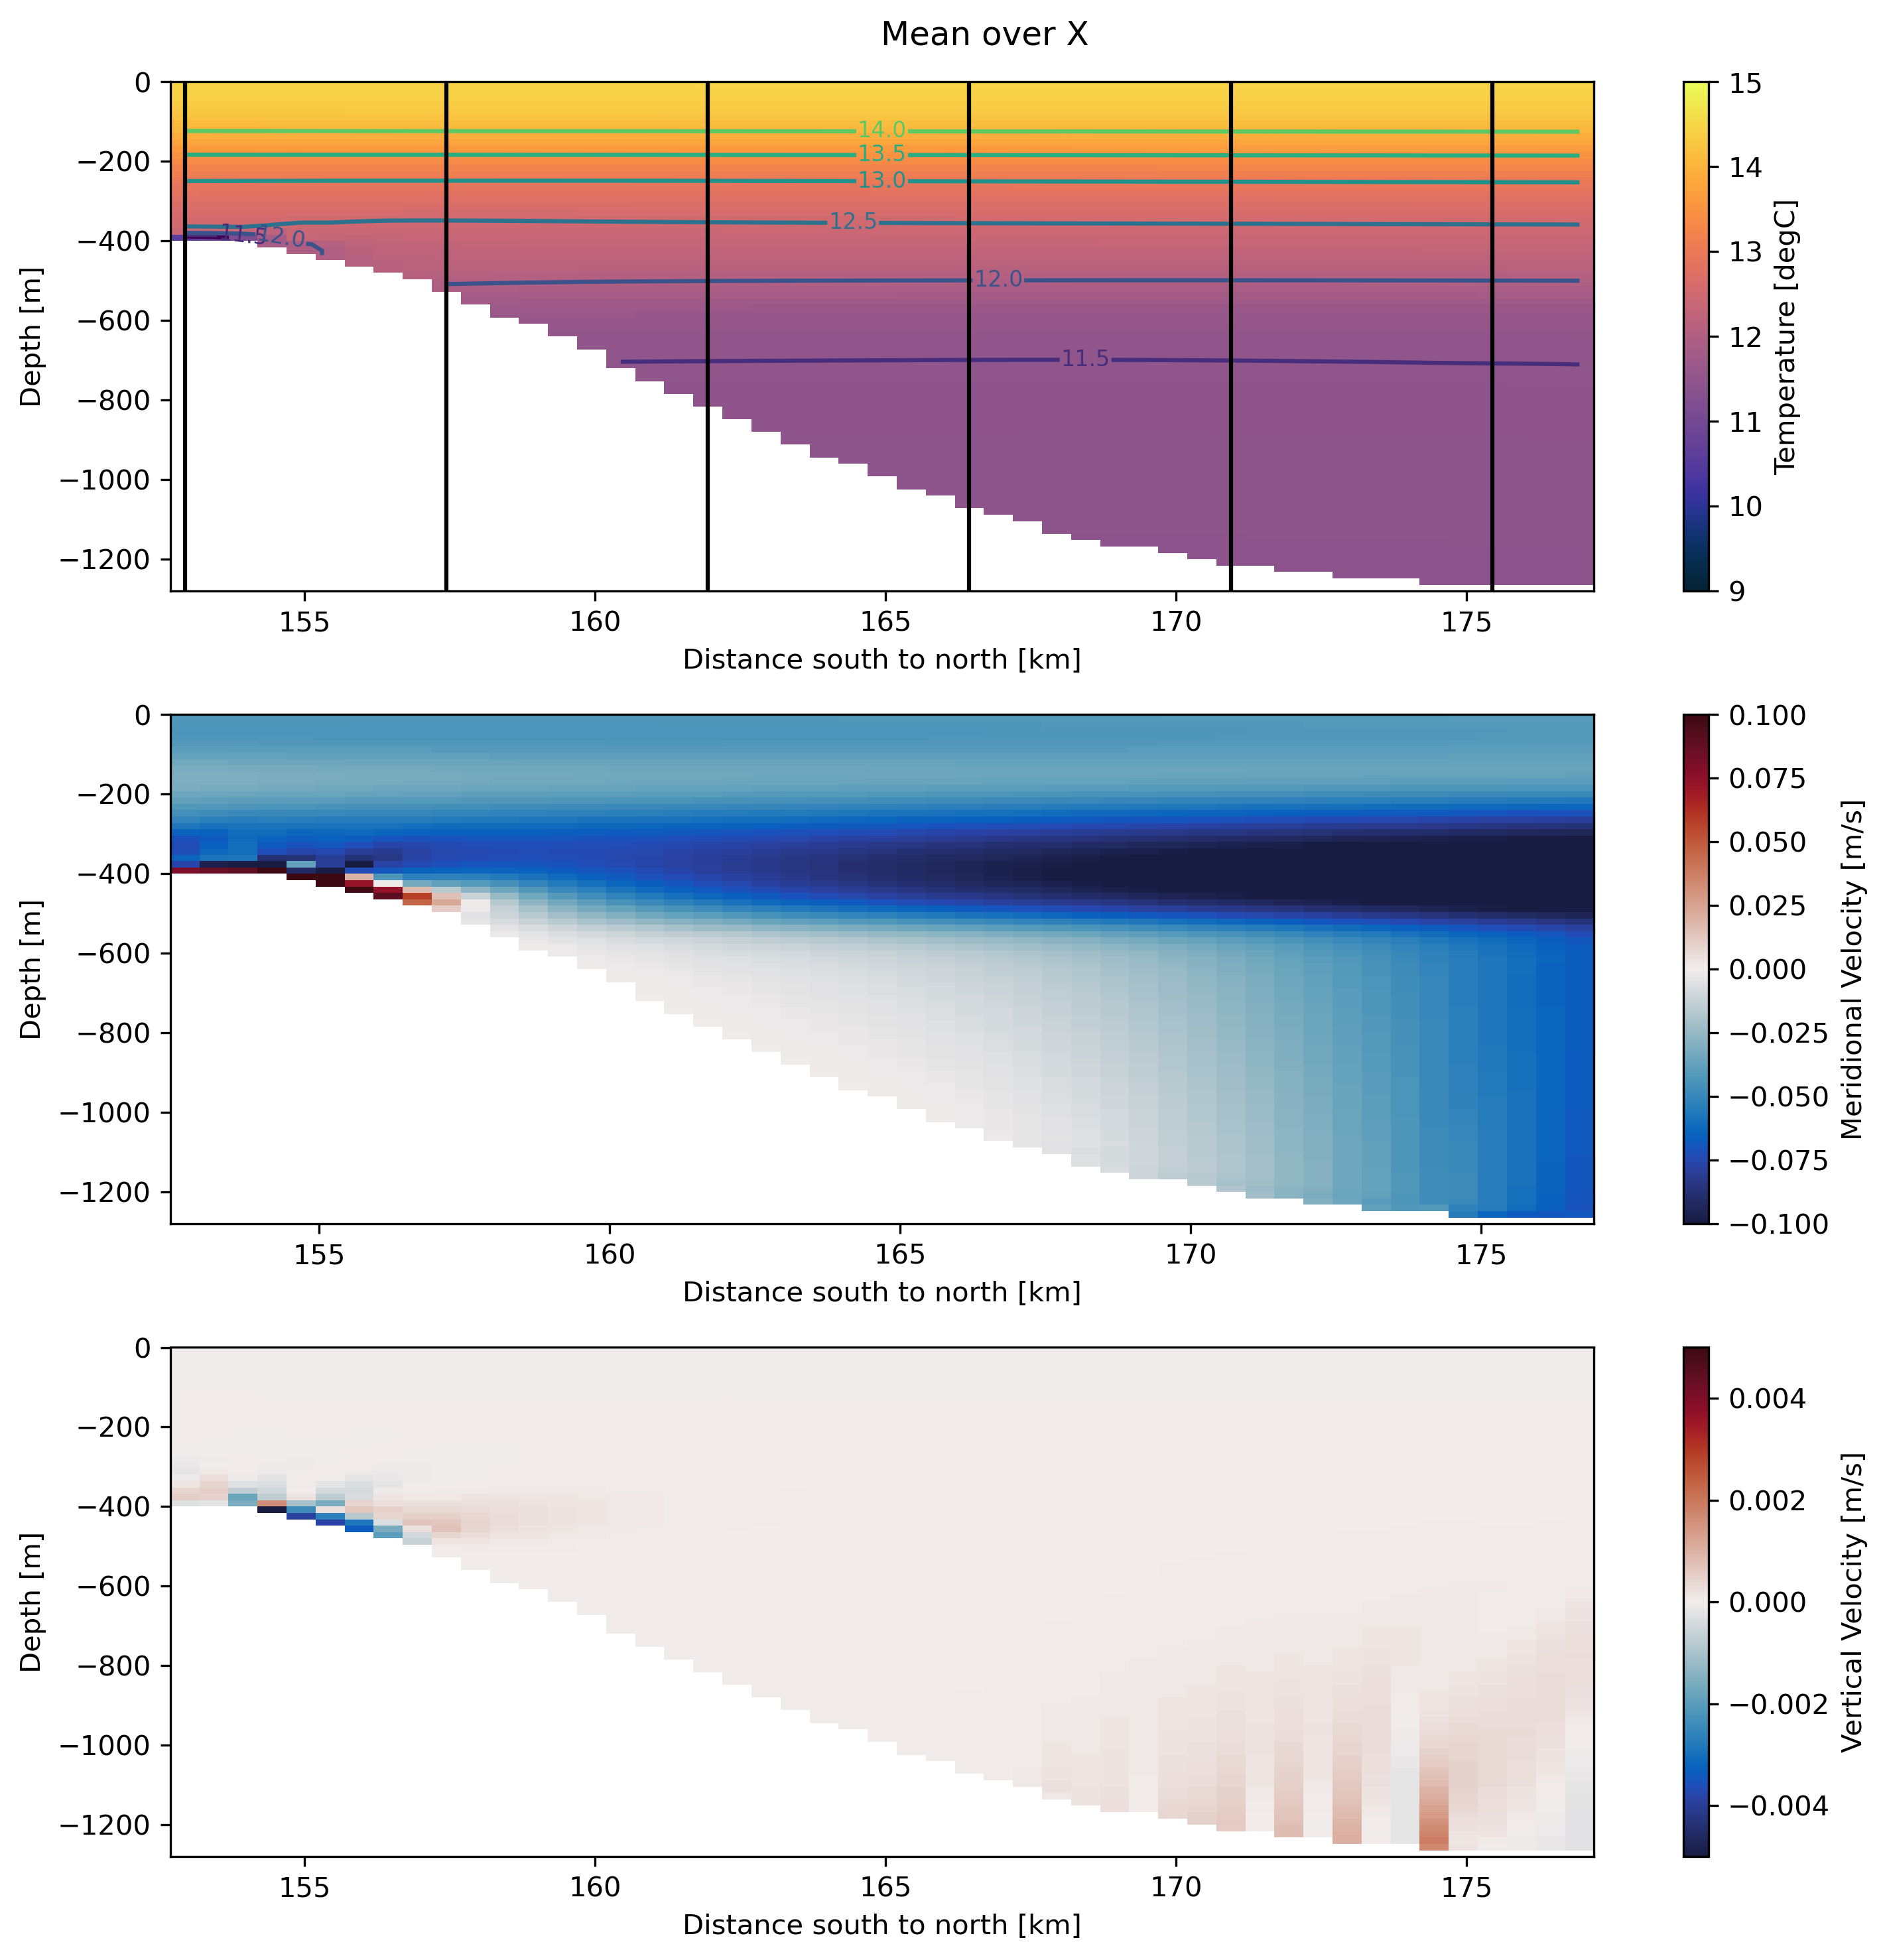

In [6]:
indX=np.arange(4,6,1) #-2#1 #int(nx/2)
end=-1

lines=np.arange(umbral1,umbralEnd1,int((umbralEnd1-umbral1)/5))

fig,ax=plt.subplots(3)
axin=ax[0]
cax=axin.pcolormesh(dsG.Y[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(ds.THETA[end,:,closS:closE,indX],mask=mask[:,closS:closE,indX]),axis=2),vmin=9,vmax=15,cmap=cmocean.cm.thermal)
levels=[11,11.5,12,12.5,13,13.5,14,15]
caxC=axin.contour(dsG.Y[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(ds.THETA[end,:,closS:closE,indX],mask=mask[:,closS:closE,indX]),axis=2),levels=levels)
axin.clabel(caxC, inline=1, fontsize=8)
for line in lines:
    axin.axvline(dsG.Y[line]/1000,color='k')

axin.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')
    
cbar=plt.colorbar(cax)
cbar.set_label('Temperature [degC]')

axin=ax[1]
cax=axin.pcolormesh(dsG.Yp1[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(ds.VVEL[end,:,closS:closE,indX],mask=masks[:,closS:closE,indX]),axis=2),vmin=-0.1,vmax=0.1,cmap=cmocean.cm.balance)

axin.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')
    
cbar=plt.colorbar(cax)
cbar.set_label('Meridional Velocity [m/s]')

axin=ax[2]
cax=axin.pcolormesh(dsG.Y[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(ds.WVEL[end,:,closS:closE,indX],mask=mask[:,closS:closE,indX]),axis=2),vmin=-0.005,vmax=0.005,cmap=cmocean.cm.balance)


cbar=plt.colorbar(cax)
cbar.set_label('Vertical Velocity [m/s]')
axin.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')
fig.suptitle('Mean over X')
fig.tight_layout()

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'CloseUpUmbMeanUmb1.png', bbox_inches='tight')

np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,umbral+step,1:int(len(dsG.X[1:-1])/2)],axis=0),mask=mask[:,umbral+step,1:int(len(dsG.X[1:-1])/2)]),axis=1)

In [48]:
umb=umbral2
umbEnd=umbralEnd2
depth=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
avvel=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
transp=np.zeros((len(dsG.Y[umb:umbEnd]),len(dsG.X[1:-1])))
k=0
for p in np.arange(umb,umbEnd,1):
    for i in np.arange(1,len(dsG.X)-1,1):
        if np.any(np.mean(ds.VVEL[start:,:,p,i],axis=0)<0)==False:
            inddep=np.argmax(np.mean(ds.VVEL[start:,:,p,i].values,axis=0))-6
            depth[k,i-1]=dsG.Z[inddep]
            avvel[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,:,p,i],axis=0),mask=mask[:,p,i]))
        else:
            inddep=np.where(np.mean(ds.VVEL[start:,:,p,i],axis=0)<0)[0][-1]
            depth[k,i-1]=dsG.Z[inddep]
            avvel[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:,inddep:,p,i],axis=0),mask=mask[inddep:,p,i]))
            maxdep=np.min(np.ma.masked_array(dsG.Z.values,mask=mask[:,p,i]))
            transp[k,i-1]=np.sum((depth[k,i-1]-maxdep)*(dsG.Xp1[i]-dsG.Xp1[i-1])*avvel[k,i-1]*1e-6)
    k=k+1


In [77]:
OBend

-20

In [29]:
params = {'font.size': 15,
          'figure.figsize': (12, 5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

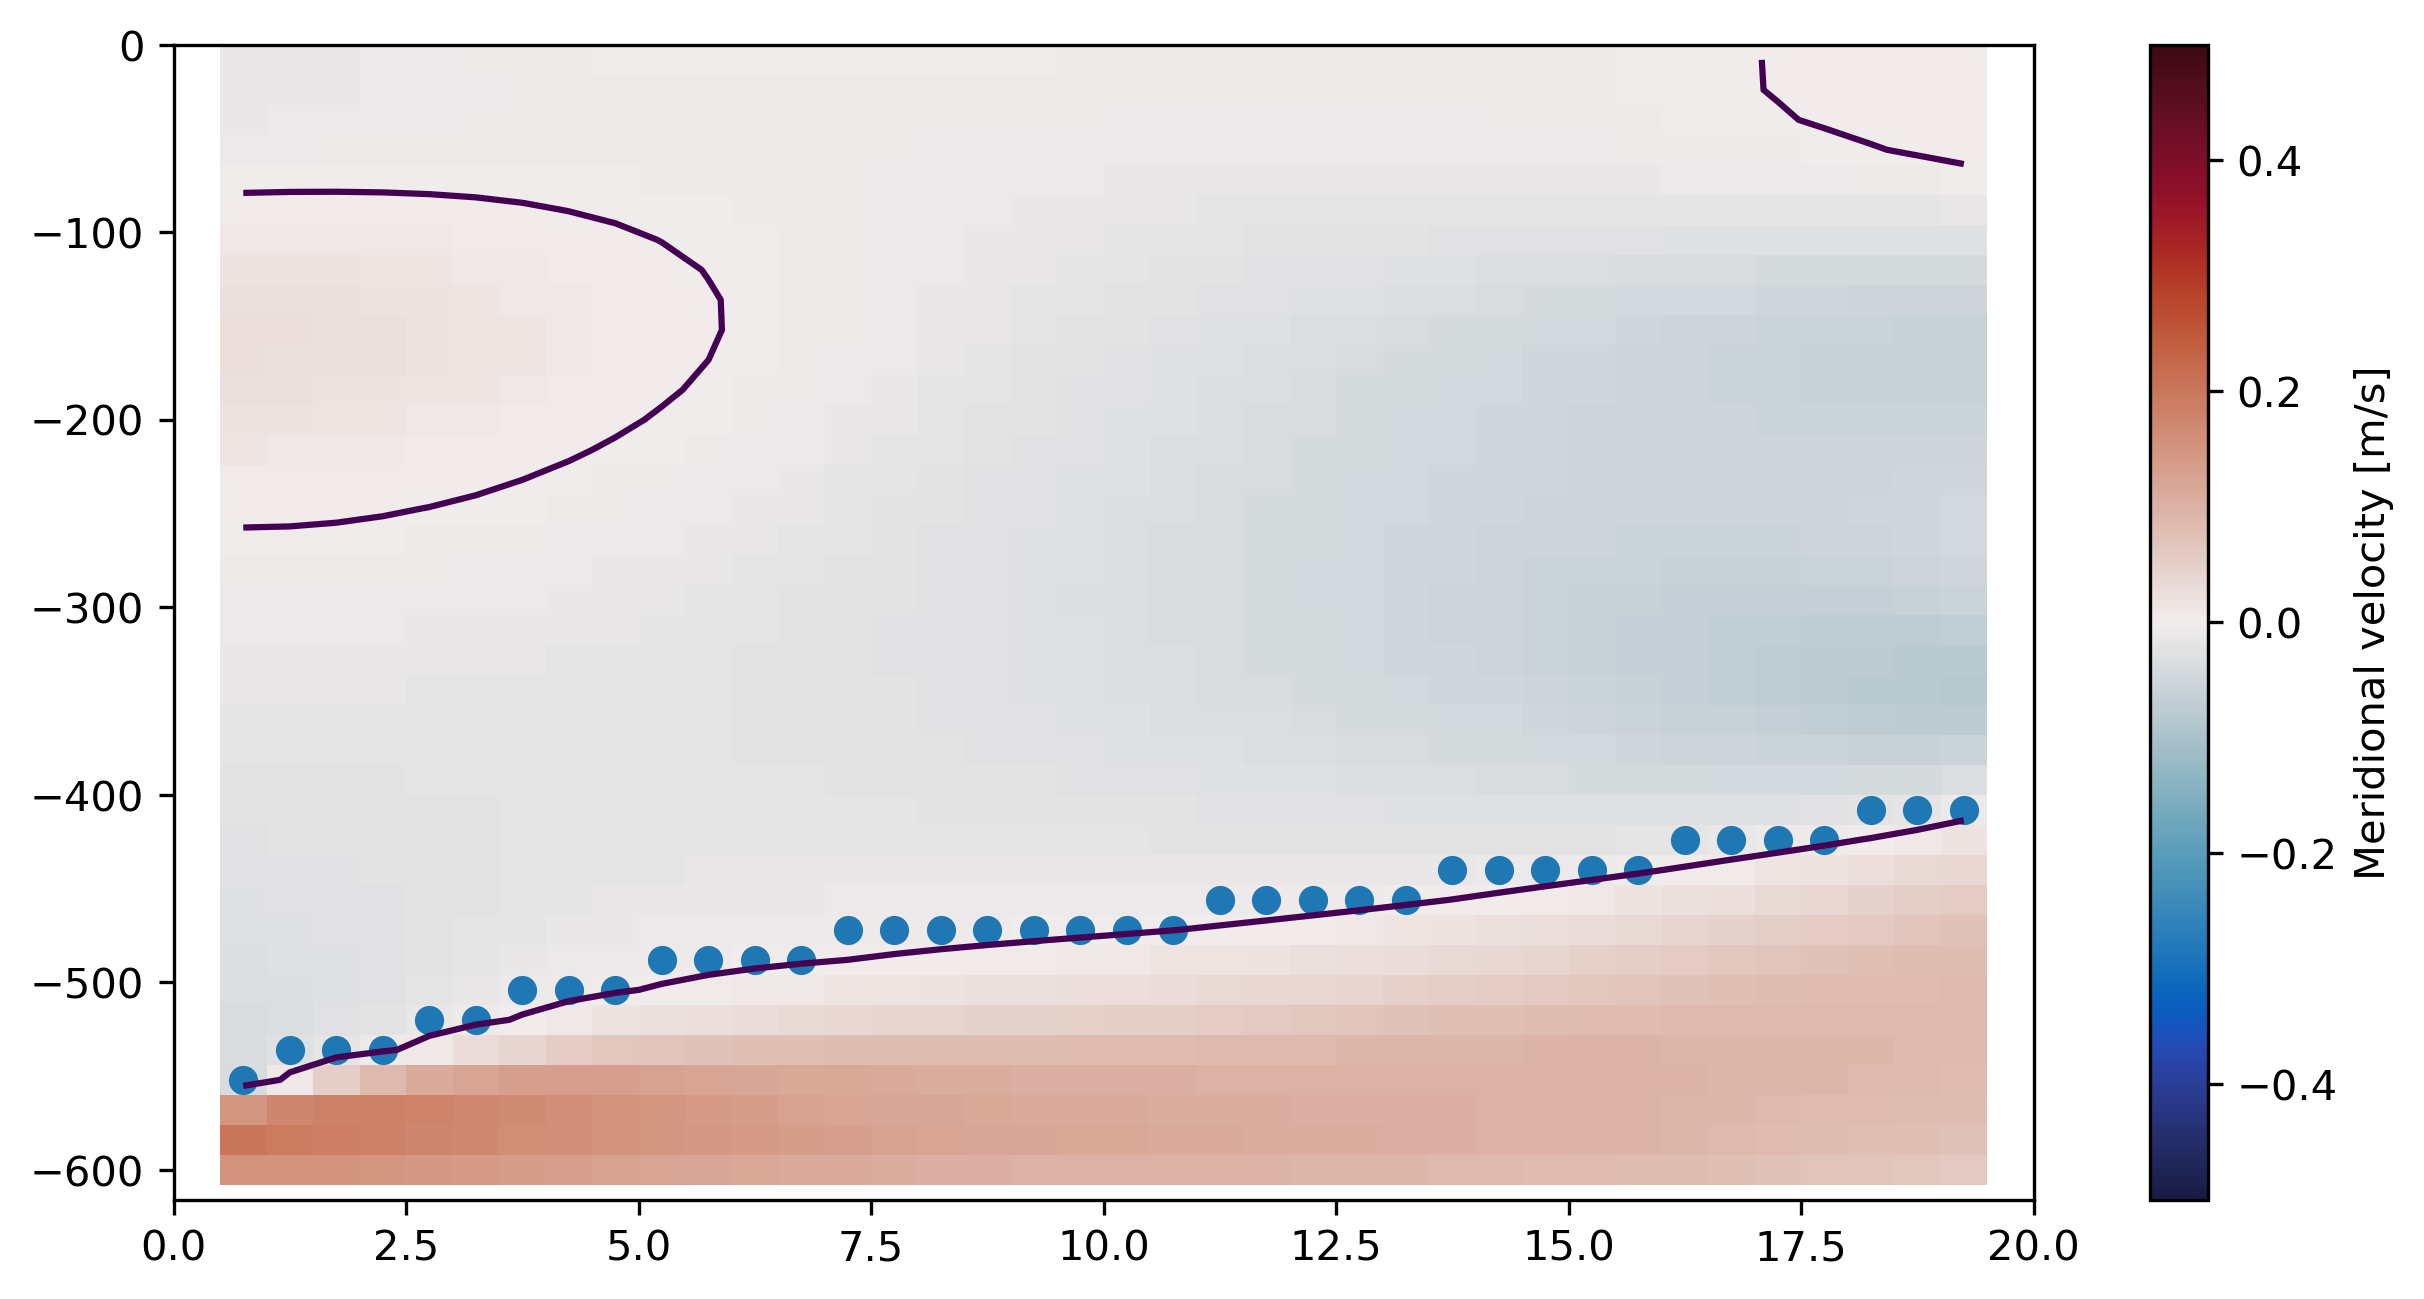

In [125]:
indy=np.arange(umbral2,umbralEnd2,1)
p=0 #np.arange(0,50,10)[0]

cax=plt.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,indy[p],:],axis=0),mask=mask[:,indy[p],:]),vmin=-0.5,vmax=0.5,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[mask[:,indy[p],5]==True][0]
plt.ylim((ymax,0))
plt.scatter(dsG.X[1:-1]/1000,depth[p])
cbar=plt.colorbar(cax)
cbar.set_label('Meridional velocity [m/s]')
plt.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,indy[p],:],axis=0),mask=mask[:,indy[p],:]),levels=[0])

#plt.text(dsG.X[27]/1000, dsG.Z[11], f' {np.sum(transp[p,int(len(dsG.X[1:-1])/2):]):.2g} SV\non east side', color='k',fontsize=8)
#plt.text(dsG.X[5]/1000, dsG.Z[11], f' {np.sum(transp[p,:int(len(dsG.X[1:-1])/2)]):.2g} SV\non west side', color='k',fontsize=8)
#plt.text(dsG.X[17]/1000, dsG.Z[10], f' {np.sum(transp[p]):.2g} SV\nin total', color='k',fontsize=8)

#plt.text(dsG.X[5]-2000, -200, f'Total transport\n{np.sum((dsG.Z[siz]-ymax)*2000*vel*1e-6):.1g} SV', color='k',fontsize=8)

#plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'MeridTransportSillTop.png', bbox_inches='tight')

In [36]:
alpha=2*1e-4
RHO=np.zeros(np.shape(ds.THETA.values))
for i in range(len(ds.T)):
    RHO[i,:,:,:]=999.8*(1-np.ma.masked_array(ds.THETA[i].values-14,mask=mask)*alpha)

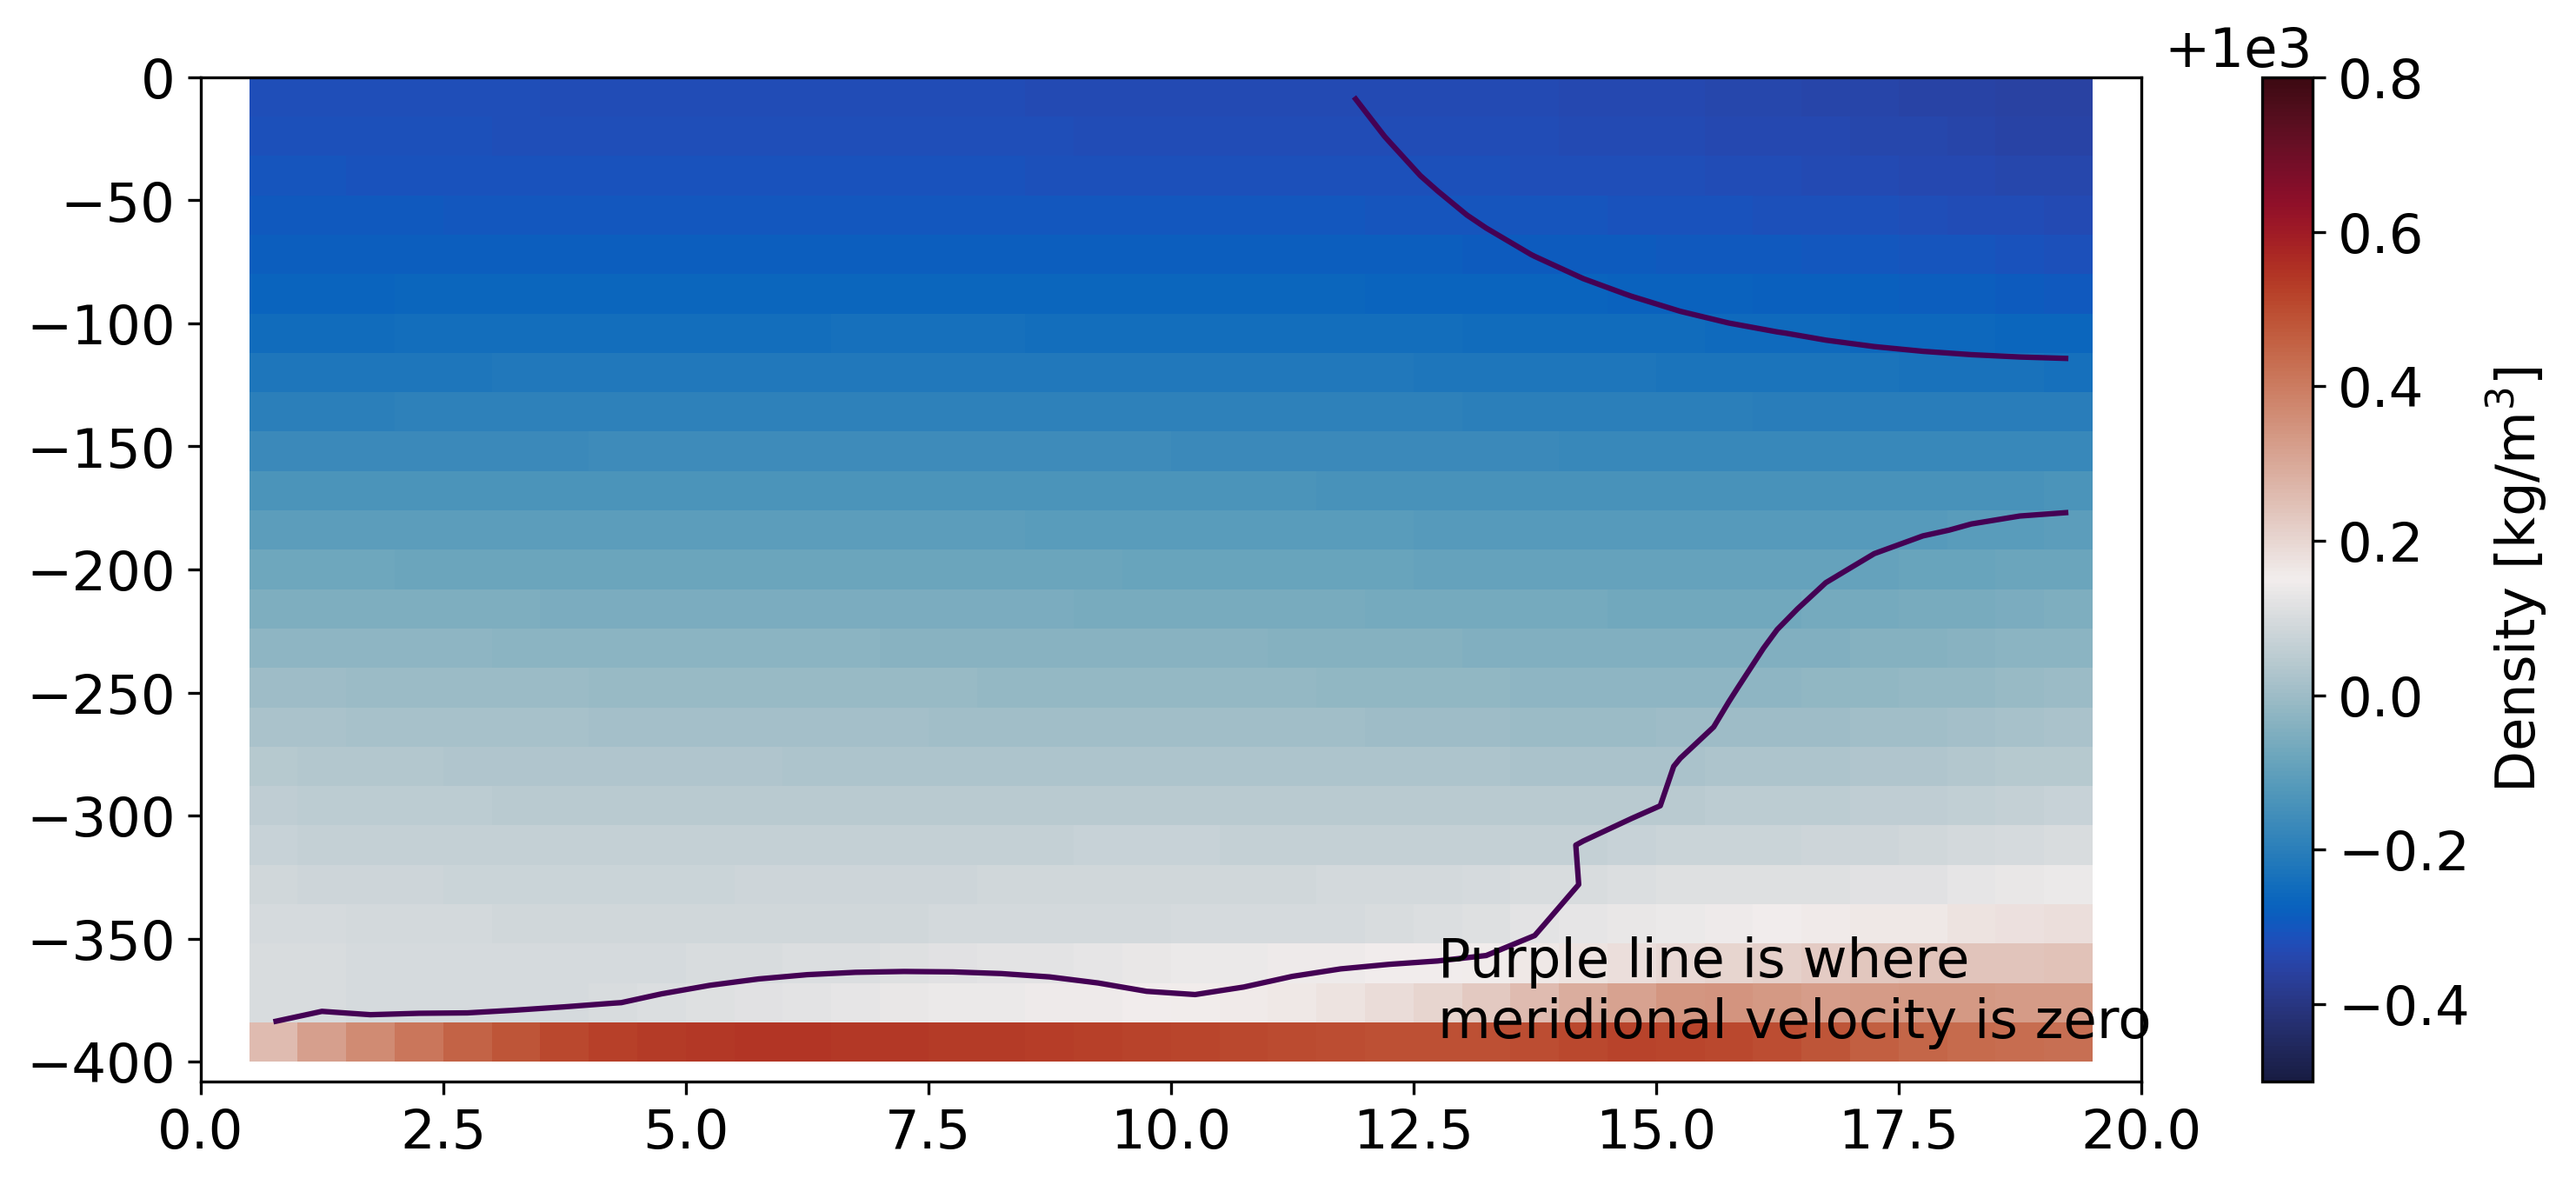

In [37]:
vmin=np.min(np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]))
vmax=-np.min(np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]))

plt.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(RHO[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]),vmin=999.5,vmax=1000.8,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[mask[:,umbral,5]==True][0]
plt.ylim((ymax,0))

cbar=plt.colorbar()
cbar.set_label('Density [kg/m$^{3}$]')
#plt.contour(dsG.X,dsG.Z[:35],ds.VVEL[-1,:35,umbral,:],levels=[0])
plt.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,umbral,:],axis=0),mask=mask[:,umbral,:]),levels=[0])
plt.text(dsG.X[25]/1000, -390, f'Purple line is where\nmeridional velocity is zero', color='k',fontsize=15)
#plt.scatter(dsG.X[1:-1],dsG.Z[siz])
#for i in range(len(siz)):
#    plt.text(dsG.X[1+i]-1000, dsG.Z[siz[i]]+40, f' {((dsG.Z[siz[i]]-ymax)*2000*vel[i]*1e-6):.1g} SV', color='k',fontsize=8)

#plt.text(dsG.X[5]-2000, -200, f'Total transport\n{np.sum((dsG.Z[siz]-ymax)*2000*vel*1e-6):.1g} SV', color='k',fontsize=8)

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'RhoTransport.png', bbox_inches='tight')

In [99]:
depindUmb=np.where(mask[:,umbral2,5])[0][0]-1

depind800=np.where(dsG.Z<-800)[0][0]

In [152]:
umbralStart2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][0]+int(ny/2)


umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]
umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)

umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)

In [94]:
def BottomConc(vel, hfac, nz,nt, ny,nx,loc):
    '''vel: Velocity field (nt,nz,ny)
       hfac: fraction of open cell at center (nz,ny)
       
       
       RETURNS:
       
       BotVel = velocity near bottom (nt,ny)'''
    
    BotVel = np.empty((nt,ny,nx))
    BottomInd = np.argmax(hfac[::-1,:,5]>0.0,axis=0) # start looking for first no-land cell from the bottom up.
    BottomInd = (np.ones(np.shape(BottomInd))*nz - BottomInd)-loc # Get index of unreversed z axis
    
    for j in range(nt):
        for i in range(ny): 
            for k in range(nx): 
                BotVel[j,i,k] = vel[j,int(BottomInd[i]),i,k] 
                
    
    return (BotVel,BottomInd.astype(int))


In [95]:
nz=len(dsG.Z)
ny=len(dsG.Y)
nt=len(ds.T)
nx=len(dsG.X)

tempOut,BottomInd=BottomConc(ds.WRHOMASS[:,:,:,:],hFacC[:,:,:].values , nz, nt, ny,nx,1)
vvelOut,BottomInd=BottomConc(ds.VVEL[:,:,:,:],hFacS[:,:,:].values , nz, nt, ny+1,nx,1)
uvelOut,BottomInd=BottomConc(ds.UVEL[:,:,:,:],hFacW[:,:,:].values , nz, nt, ny,nx+1,1)

In [96]:
params = {'font.size': 15,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

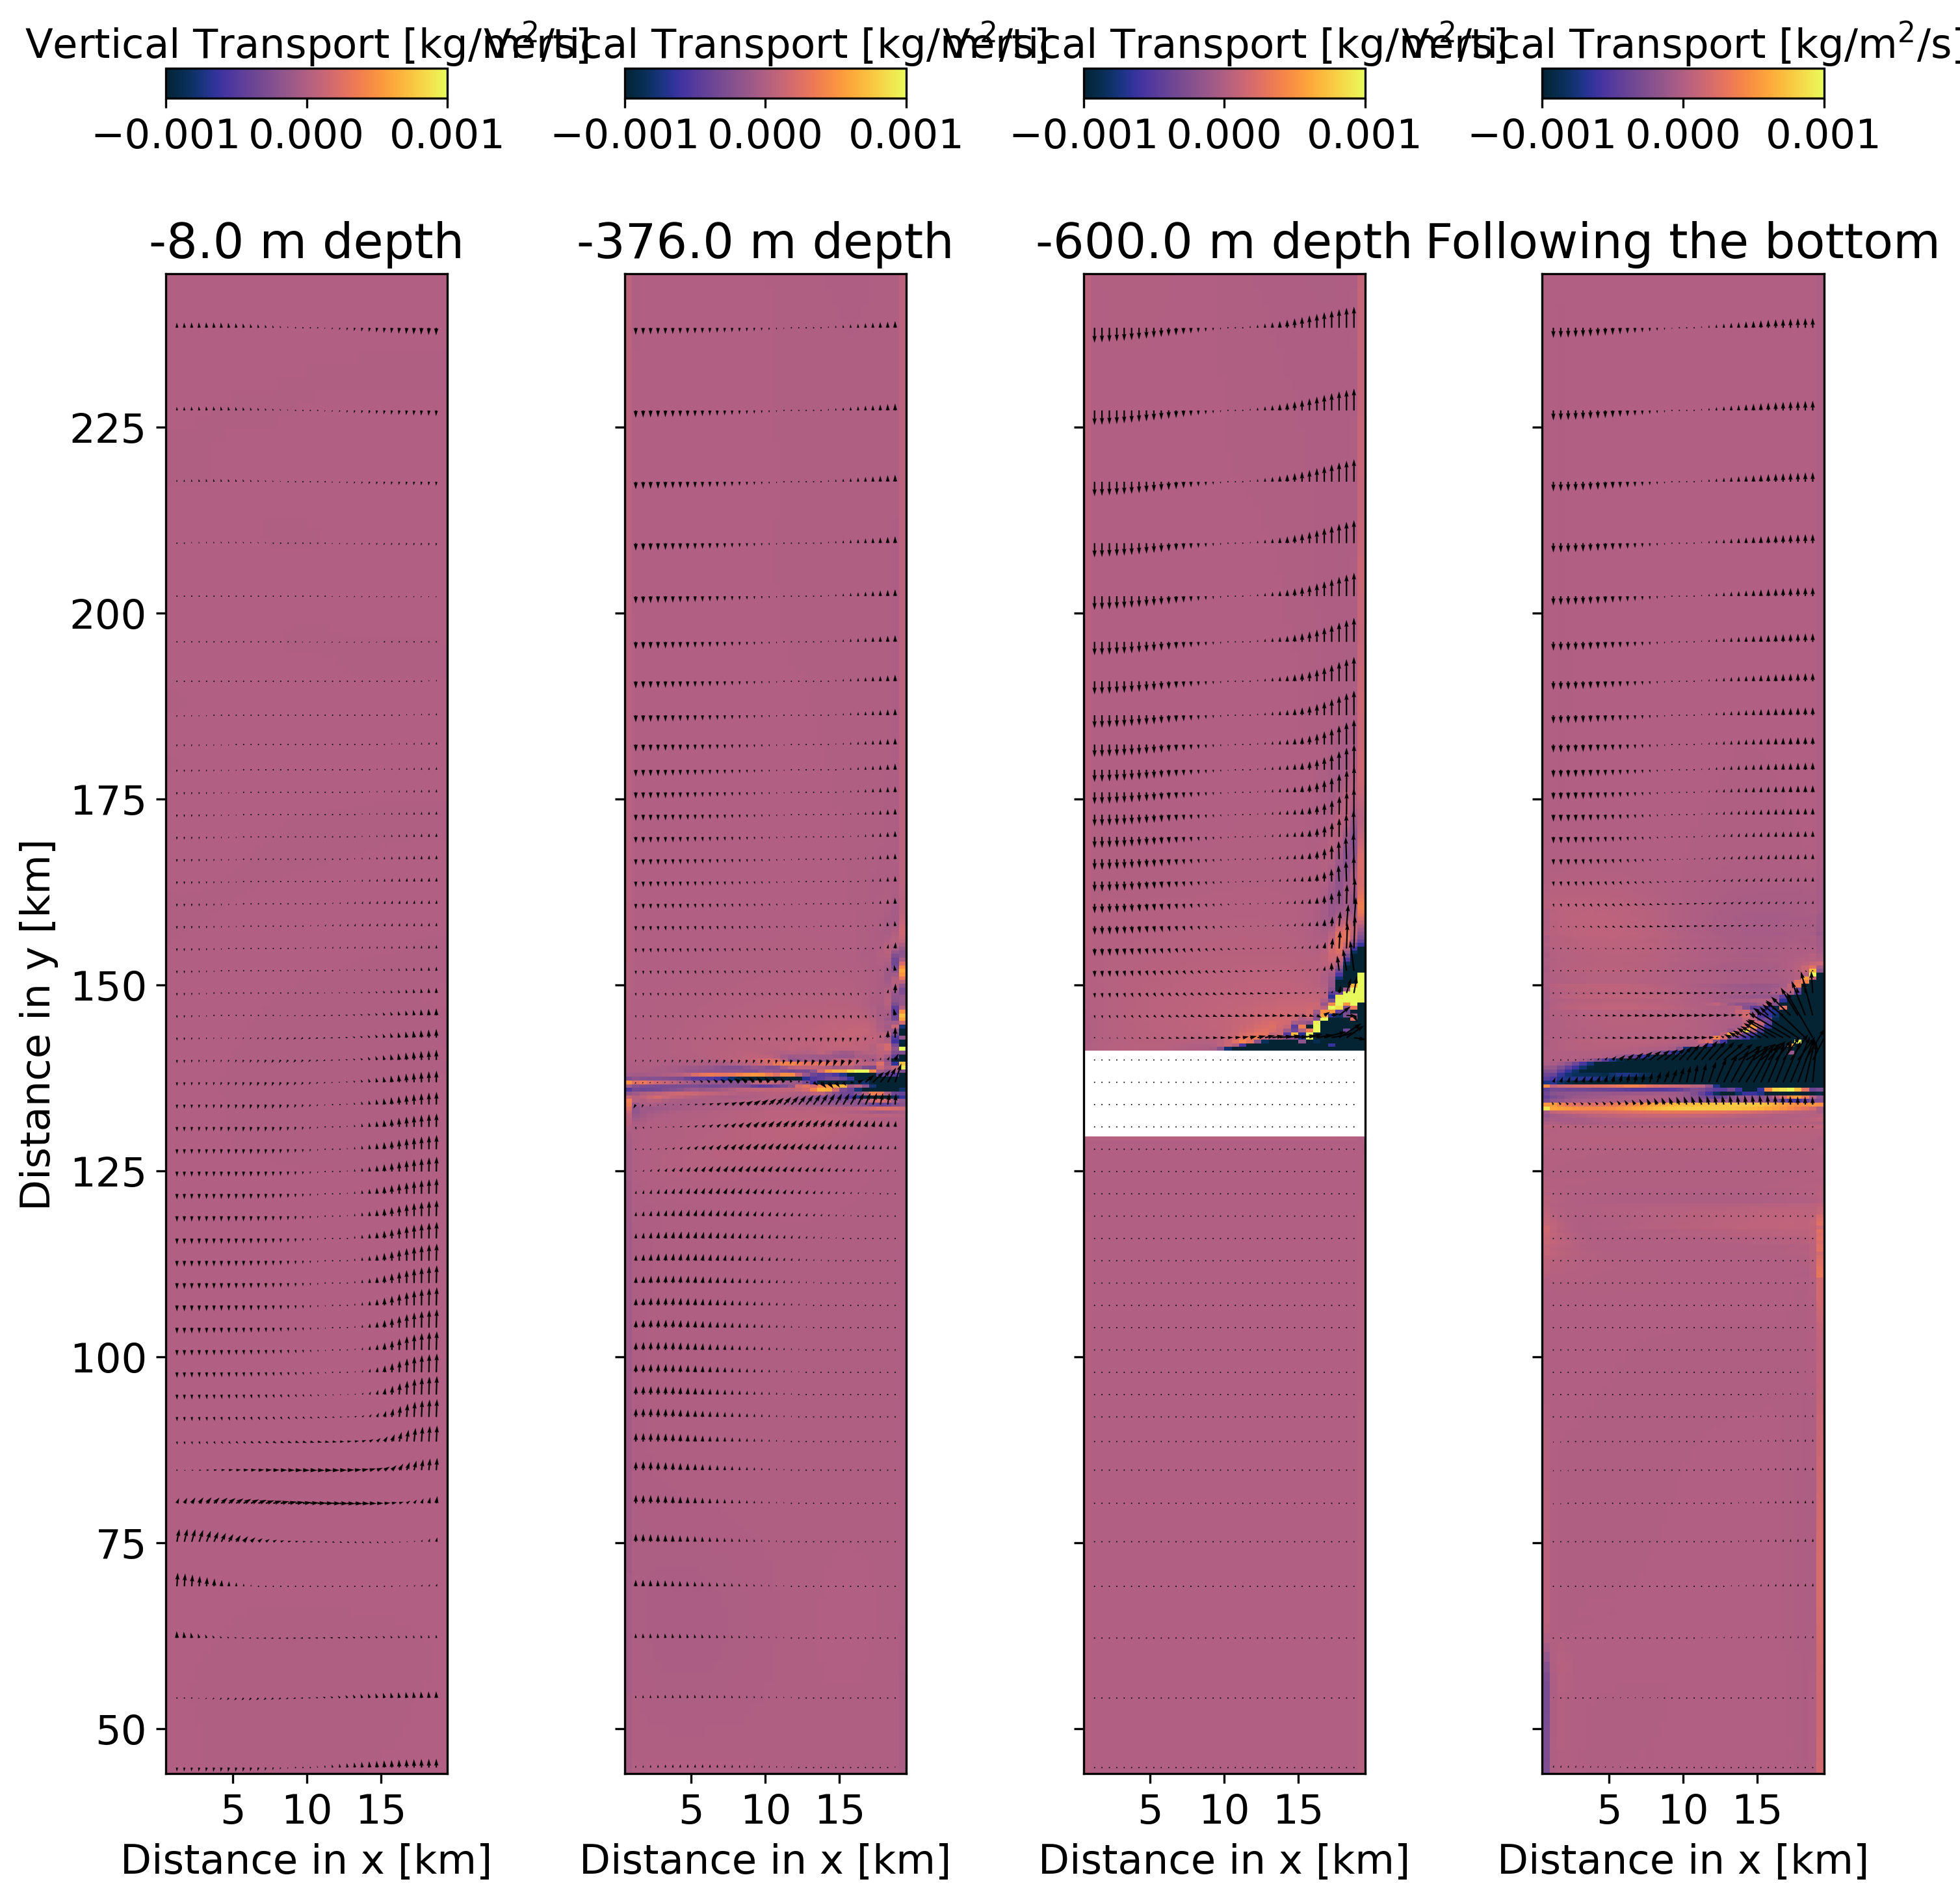

In [97]:
t=0
space=6
spacex=1
dep=[0,23,37]
VARS=list(ds.keys())[:]
widths = 0.005# np.linspace(0, 2, dsG.X[OBx:OBendx].values.size)

#for variable in VARS:

variable=VARS[2]

varin=ds.WRHOMASS
title= 'Vertical Transport [kg/m$^2$/s]'

Yin=dsG.Y
Xin=dsG.X[OBx:OBendx]

cmapi=cmocean.cm.thermal

fig,ax=plt.subplots(1,4)


tin=-1


axin=ax[0]
vmin=-0.001 #np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
vmax=0.001 #-np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
axin.set(xlabel='Distance in x [km]',ylabel='Distance in y [km]')

timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[0],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[0],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[0]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[0],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[0],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[1]

#vmin=11 #np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
#vmax=13 #-np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[1],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[1],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[1]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[1],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[1],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[2]

#vmin=11 #np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
#vmax=12 # -np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.ma.masked_array(np.mean(varin[start:end,dep[2],OB:OBend,OBx:OBendx],axis=0),mask=mask[dep[2],OB:OBend,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'{dsG.Z[dep[2]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(ds.VVEL[start:end,dep[2],OB:OBend,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(ds.UVEL[start:end,dep[2],OB:OBend,:].values,axis=0))
U=interpU((gridY,gridX))

gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:], width=widths)


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[3]

#vmin= 10#np.min(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
#vmax= 12#np.max(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')

indmean=23
timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin[OB:OBend]/1000, np.mean(tempOut[start:end,OB:OBend,OBx:OBendx],axis=0),vmin=vmin,vmax=vmax,cmap=cmapi)


gridY,gridX=np.meshgrid(Yin[OB:OBend].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((dsG.Yp1[OB:OBend].values,dsG.X.values),np.mean(vvelOut[start:end,OB:OBend,:],axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((dsG.Y[OB:OBend].values,dsG.Xp1.values),np.mean(uvelOut[start:end,OB:OBend,:],axis=0))
U=interpU((gridY,gridX))
gridXind=gridX[np.arange(0,len(gridY[:,0]),spacex),:]
gridYind=gridY[np.arange(0,len(gridY[:,0]),spacex),:]
Uind=U[:,np.arange(0,len(gridY[0,:]),space)]
Vind=V[:,np.arange(0,len(gridY[0,:]),space)]

axin.quiver(gridXind[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridYind[:,np.arange(0,len(gridY[0,:]),space)]/1000,Uind[np.arange(0,len(gridY[:,0]),spacex),:],Vind[np.arange(0,len(gridY[:,0]),spacex),:],width=widths)

axin.set(title=f'Following the bottom')


divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

fig.tight_layout()

fig.patch.set_alpha(0.0)
plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'WtranspDifDepths.png', bbox_inches='tight')